## Configuration for L96

In [58]:
import torch
from lorenz import Lorenz96TwoLevel
import matplotlib.pyplot as plt

params = {
    "F":8,
    "b":10,
    "h":1,
    "c":10
}

l96 = Lorenz96TwoLevel(**params)

N = 36 
J = 10
x0 = torch.randn(1,N)*0.05
y0 = torch.zeros(1,N,J)



In [59]:
T = 20
dt = 0.005
t = torch.arange(0,T,dt)
x,y = l96(T,dt,x0,y0)

In [60]:
x.shape

torch.Size([1, 4000, 36])

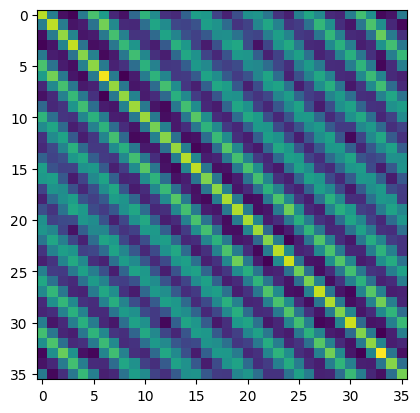

In [61]:
full_cov_matrix = torch.cov(x[0].T)
plt.imshow(full_cov_matrix.detach())
eigenvalues_full,eigenvectors_full = torch.linalg.eigh(full_cov_matrix)

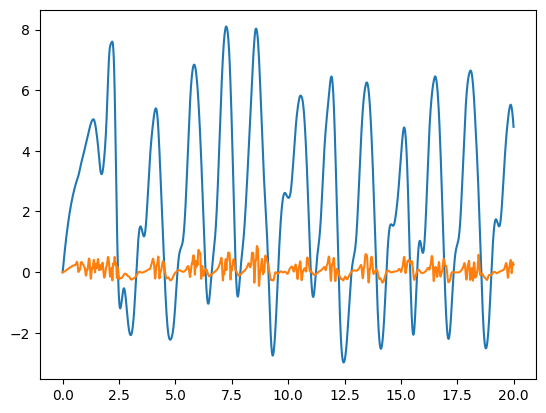

In [62]:
with torch.no_grad():
    plt.plot(t,x[0,:,0])
    plt.plot(t,y[0,:,0,0])

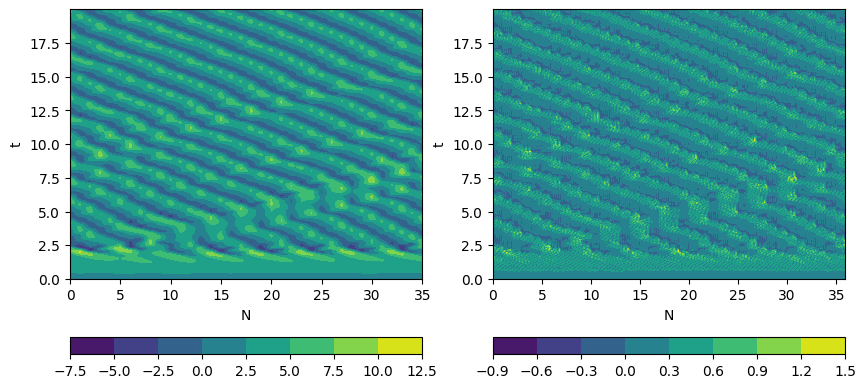

In [63]:
fig, (axX,axY) = plt.subplots(1,2,figsize=(10,5))
with torch.no_grad():
    Ns,Ts = torch.meshgrid(torch.arange(0,N).float(),t,indexing='xy')
    Nys,Tys = torch.meshgrid(torch.arange(0,N,1/J).float(),t,indexing='xy')
    xC = axX.contourf(Ns,Ts,x[0])
    yC = axY.contourf(Nys,Tys,y[0].view(-1,N*J))
    axX.set_xlabel("N")
    axX.set_ylabel("t")
    axY.set_xlabel("N")
    axY.set_ylabel("t")
    plt.colorbar(xC,orientation="horizontal",ax=axX)
    plt.colorbar(yC,orientation="horizontal",ax=axY)    



### many inputs

In [ ]:
from lorenz import TimeAveragedFeatures
T = 20 
dt = 0.005
t = torch.arange(0,T,dt)

x0 = torch.randn(100,N)*0.05
y0 = torch.zeros(100,N,J)

l96_avg = TimeAveragedFeatures(l96,spinup=5,degree=2)

x_avg,y_avg = l96_avg(T,dt,x0,y0)



In [8]:
from torch.distributions import MultivariateNormal

data = MultivariateNormal(x_avg.mean(dim=0),torch.cov(x_avg.T))

In [9]:
data.covariance_matrix

tensor([[ 0.1479,  0.0273, -0.0014,  ...,  0.1284,  0.0062,  0.0052],
        [ 0.0273,  0.1356,  0.0073,  ...,  0.0383,  0.1110, -0.0070],
        [-0.0014,  0.0073,  0.1127,  ..., -0.0064,  0.0206,  0.1082],
        ...,
        [ 0.1284,  0.0383, -0.0064,  ...,  0.1447,  0.0204, -0.0184],
        [ 0.0062,  0.1110,  0.0206,  ...,  0.0204,  0.1243,  0.0076],
        [ 0.0052, -0.0070,  0.1082,  ..., -0.0184,  0.0076,  0.1347]],
       dtype=torch.float64, grad_fn=<ExpandBackward0>)

### History Matching

In [10]:
x_avg_norm = (x_avg - x_avg.mean(dim=0))/x_avg.std(dim=0)
data_norm = MultivariateNormal(x_avg_norm.mean(dim=0),torch.cov(x_avg_norm.T))

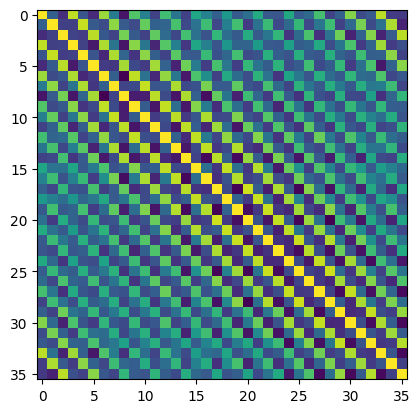

In [11]:
plt.imshow(data_norm.covariance_matrix.detach())

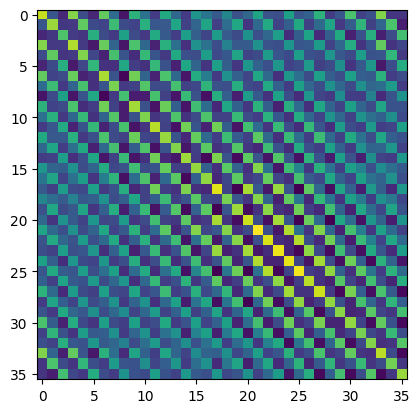

In [12]:
plt.imshow(data.covariance_matrix.detach())

In [13]:
covariance = torch.cov(x_avg.T)
eigenvalues,eigenvectors = torch.linalg.eigh(covariance)

In [14]:
eof0 =eigenvectors_full[:,-1]
pc0 = x@eigenvectors_full[:,-1]
eof1 = eigenvectors_full[:,-2]
pc1 = x@eigenvectors_full[:,-2]
eof2 = eigenvectors_full[:,-3]
pc2= x@eigenvectors_full[:,-3]

In [15]:
eigenvalues_full.numel()

36

In [16]:
recon = torch.sum(torch.stack([ torch.outer(x[0]@eigenvectors_full[:,i],eigenvectors_full[:,i]) for i in range(-1,-5,-1)]),dim=0)

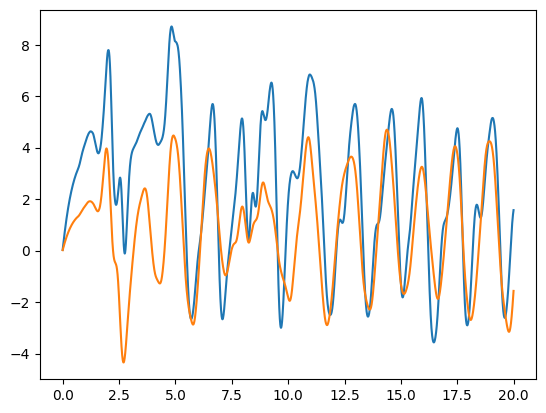

In [17]:
with torch.no_grad():
    plt.plot(t,x[0,:,1])    
    plt.plot(t,recon[:,1])  

In [18]:
from abracalibra.forward_model import ForwardModel

x0 = torch.randn(1,N)*0.05
y0 = torch.zeros(1,N,J)
T = 20
dt = 0.005

def l96(h,c,b,F):
    with torch.no_grad():
        l96 = TimeAveragedFeatures(Lorenz96TwoLevel(h=h,c=c,b=b,F=F),spinup=5,degree=1)
        x,_ = l96(T,dt,x0,y0)
        return (x[0] - x_avg.mean(dim=0))/(x_avg.std(dim=0))

fwd = ForwardModel(l96,vectorized=False)

In [19]:
from abracalibra.history_matching import HistoryMatchingBase    
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from abracalibra.emulators import MultiTaskGP
from gpytorch.distributions import MultitaskMultivariateNormal
from gpytorch.mlls import ExactMarginalLogLikelihood    
from gpytorch.priors import NormalPrior, LogNormalPrior
from gpytorch.models import ExactGP
from gpytorch.means import ZeroMean,MultitaskMean
from gpytorch.constraints import GreaterThan
from gpytorch.kernels import RBFKernel,MultitaskKernel

class Lorenz96GP(ExactGP):
    def __init__(self, train_x, train_y, likelihood, num_tasks, rank=1):
        super(Lorenz96GP, self).__init__(train_x, train_y, likelihood)
        self.num_tasks = num_tasks
        self.mean_module = MultitaskMean(ZeroMean(),num_tasks=num_tasks)
        self.base_covar_module = RBFKernel(ard_num_dims=4,lengthscale_constraint=GreaterThan(0.1),lengthscale_prior=LogNormalPrior(0, 1))
        self.covar_module = MultitaskKernel(
            self.base_covar_module, num_tasks=num_tasks, rank=rank
        )


    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultitaskMultivariateNormal(mean=mean_x, covariance_matrix=covar_x)

class HistoryMatchingLorenz(HistoryMatchingBase):
    def make_emulator(self, parameters, observations):
        if self.output_mc_batchshape:
            target_shape = torch.Size((*parameters.shape[:-1], *self.output_mc_batchshape, self.number_of_parameters))
            parameters = parameters.unsqueeze(-2).expand(*target_shape)
            parameters = parameters.reshape(-1, self.number_of_parameters)
        else:
            parameters = parameters.view(-1, self.number_of_parameters)
        observations = observations.view(-1, self.number_of_observables)
        likelihood = MultitaskGaussianLikelihood(
            num_tasks=self.number_of_observables,
            has_task_noise=False,
            noise_prior=NormalPrior(1,0.001)

        )
        likelihood.noise = 1 
        model = Lorenz96GP(
            parameters,
            observations,
            likelihood=likelihood,
            num_tasks=self.number_of_observables,
        ).float()
        optim = torch.optim.Adam(model.parameters(), lr=0.05)
        mll = ExactMarginalLogLikelihood(likelihood, model)
        for i in range(250):
            optim.zero_grad()
            output = model(parameters)
            loss = -mll(output, observations)
            loss.backward()
            optim.step()
            print(f"Step {i} Loss: {loss.item()}")
        model.eval()
        return model

/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [55]:
from torch.distributions import Uniform
parameters = ['h','c','b','F']
priors = {
    'h':Uniform(0.5,4),
    'c':Uniform(5,15),
    'b':Uniform(5,15),
    'F':Uniform(5,15)
}

def summary(y,true_y):
    return torch.max(torch.abs(y.mean - true_y.mean)/torch.sqrt(y.variance + true_y.variance),dim=-1).values

hm = HistoryMatchingLorenz(parameters,priors,data,ensemble_size=40,summary=summary,forward=fwd,implausibility_cutoff=3)
hm.calibrate(5)

Step 0 Loss: 2.7468106746673584
Step 1 Loss: 3.0638210773468018
Step 2 Loss: 2.731653928756714
Step 3 Loss: 2.7575771808624268
Step 4 Loss: 2.852094888687134
Step 5 Loss: 2.780285596847534
Step 6 Loss: 2.6444880962371826
Step 7 Loss: 2.5636768341064453
Step 8 Loss: 2.5632565021514893
Step 9 Loss: 2.573392868041992
Step 10 Loss: 2.528934955596924
Step 11 Loss: 2.4403867721557617
Step 12 Loss: 2.356752634048462
Step 13 Loss: 2.3102385997772217
Step 14 Loss: 2.2920241355895996
Step 15 Loss: 2.268649101257324
Step 16 Loss: 2.2198925018310547
Step 17 Loss: 2.154947519302368
Step 18 Loss: 2.0973196029663086
Step 19 Loss: 2.061352014541626
Step 20 Loss: 2.0405209064483643
Step 21 Loss: 2.016524076461792
Step 22 Loss: 1.979287028312683
Step 23 Loss: 1.9354064464569092
Step 24 Loss: 1.8985675573349
Step 25 Loss: 1.8751131296157837
Step 26 Loss: 1.859014868736267
Step 27 Loss: 1.839717149734497
Step 28 Loss: 1.8133457899093628
Step 29 Loss: 1.7853405475616455
Step 30 Loss: 1.7634236812591553
Ste

NanError: cholesky_cpu: 51840000 of 51840000 elements of the torch.Size([7200, 7200]) tensor are NaN.

In [54]:
print(hm.nroy(torch.tensor([params['h'],params['c'],params['b'],params['F']]).float()))
hm.implausibility(torch.tensor([params['h'],params['c'],params['b'],params['F']]).float(),2)

tensor([True])


tensor([2.6463], dtype=torch.float64, grad_fn=<CatBackward0>)

In [22]:
coords = hm.get_support_axis(0,50)

In [23]:
from gpytorch.settings import fast_pred_var
H,C,B,F = torch.meshgrid(*coords,indexing='ij')
X = torch.stack([H,C,B,F],dim=-1).view(-1,4)
with torch.no_grad(),fast_pred_var():
    imp = hm.implausibility(X,0,verbose=True)

torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True


In [24]:
imp = imp.view(H.shape)


In [25]:
torch.save(imp,"imp_l96.pt")

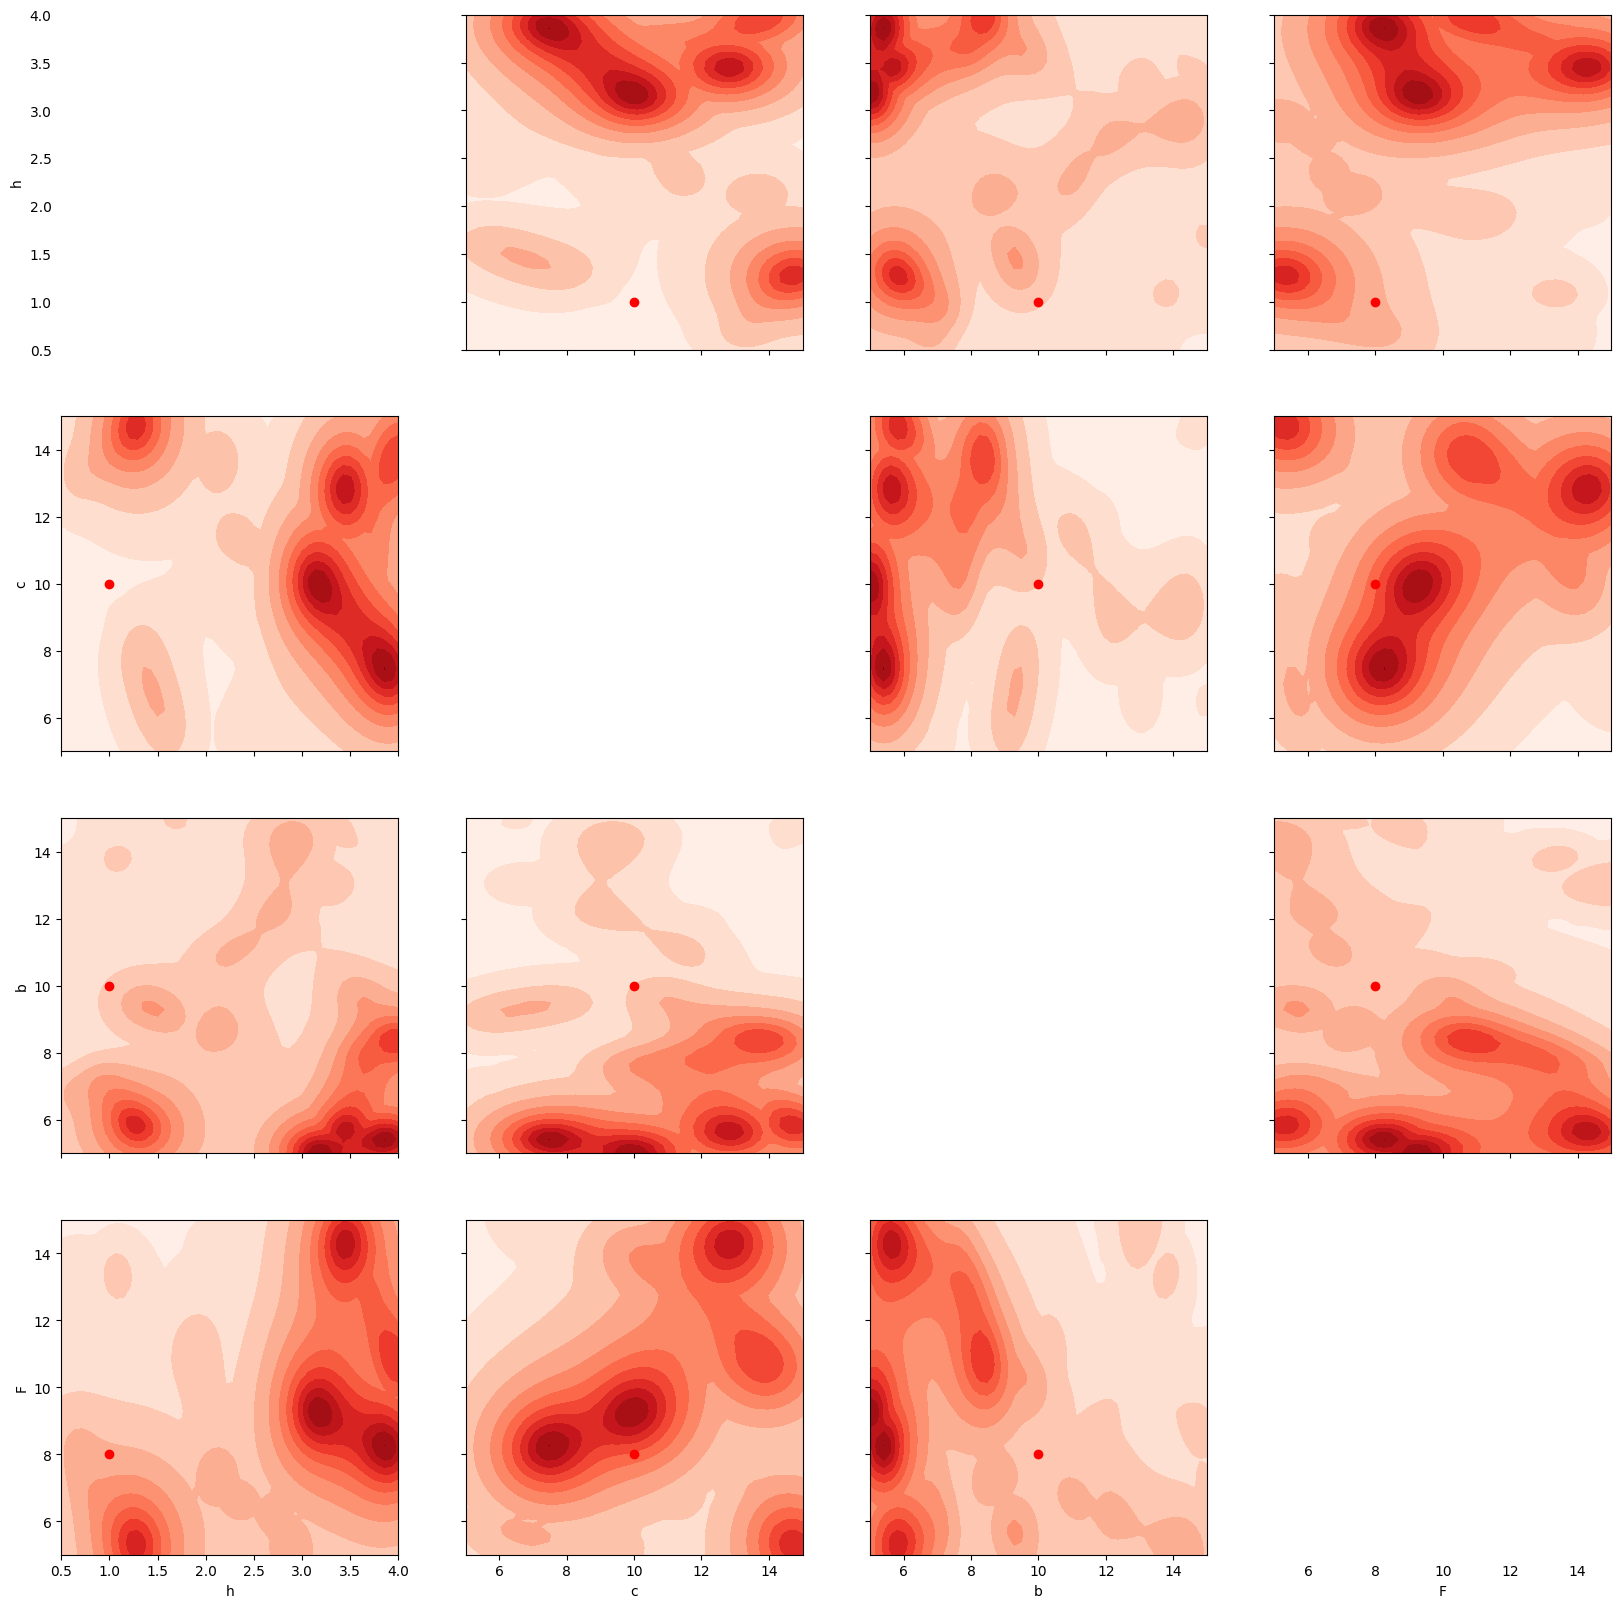

In [26]:
fig,ax = plt.subplots(4,4,figsize=(20,20),sharex='col',sharey='row')    
for i,p1 in enumerate(coords):
    for j,p2 in enumerate(coords):
        if i == 3:
            ax[i][j].set_xlabel(hm.parameter_names[j])
        
        if j == 0:
            ax[i][j].set_ylabel(hm.parameter_names[i])
        if i == j: 
            # ax[i][j].xaxis.set_visible(False)
            ax[i][j].tick_params(left=False,bottom=False)    
              # ax[i][j].yaxis.set_visible(False)
            plt.setp(ax[i][j].spines.values(), visible=False)
            continue

        values = set(range(len(coords))) - {i} - {j}
        X,Y = torch.meshgrid(p2,p1,indexing='xy')
        imp_max = torch.amax(imp,dim=tuple(values))
        if i < j:
            c= ax[i][j].contourf(X,Y,imp_max,cmap='Reds',levels=10)
        if i > j:
            c= ax[i][j].contourf(X,Y,imp_max.T,cmap='Reds',levels=10)

        ax[i][j].scatter(params[hm.parameter_names[j]],params[hm.parameter_names[i]],color='red')





In [27]:
nroy = (imp <= 3).detach()

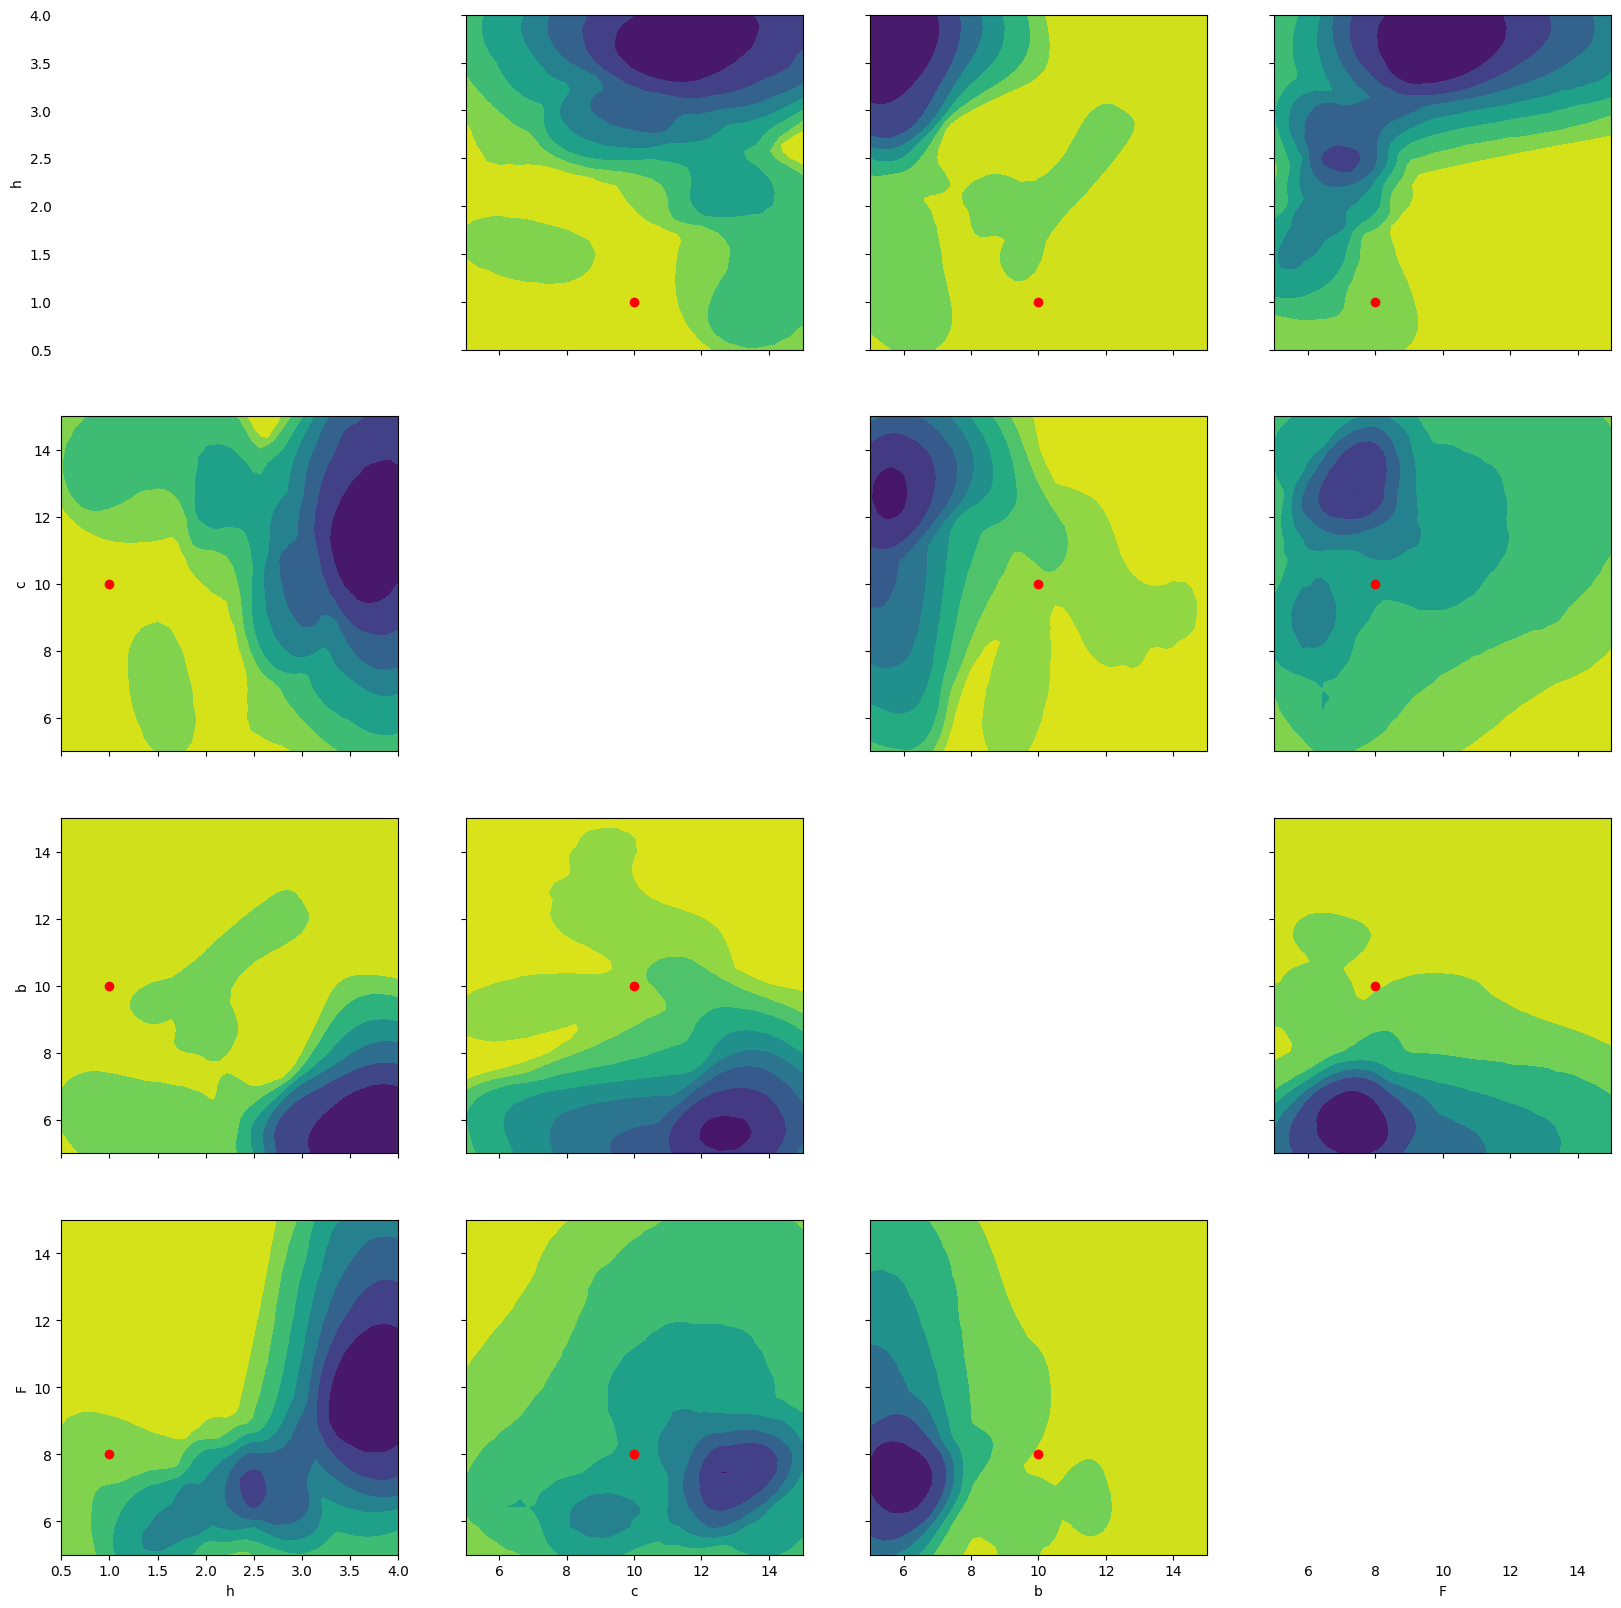

In [28]:
fig,ax = plt.subplots(4,4,figsize=(20,20),sharex='col',sharey='row')    
for i,p1 in enumerate(coords):
    for j,p2 in enumerate(coords):
        if i == 3:
            ax[i][j].set_xlabel(hm.parameter_names[j])
        
        if j == 0:
            ax[i][j].set_ylabel(hm.parameter_names[i])
        if i == j: 
            # ax[i][j].xaxis.set_visible(False)
            ax[i][j].tick_params(left=False,bottom=False)    
              # ax[i][j].yaxis.set_visible(False)
            plt.setp(ax[i][j].spines.values(), visible=False)
            continue

        values = set(range(len(coords))) - {i} - {j}
        X,Y = torch.meshgrid(p2,p1,indexing='xy')
        nroy_dim = torch.sum(nroy,dim=tuple(values))/(50*50)
        if i < j:
            ax[i][j].contourf(X,Y,nroy_dim.detach(),cmap='viridis')
        if i > j:
            ax[i][j].contourf(X,Y,nroy_dim.detach().T,cmap='viridis')

        ax[i][j].scatter(params[hm.parameter_names[j]],params[hm.parameter_names[i]],color='red')

### use DATA EOFS

In [56]:
cov_x_avg = torch.cov(x_avg.T)
eigenval_xavg,eigenvec_xavg = torch.linalg.eigh(cov_x_avg)  

In [57]:
eigenvals = eigenval_xavg[-4:]
eigenvecs = eigenvec_xavg[:,-4:]
print(eigenvals.sum()/eigenval_xavg.sum())

tensor(0.8254, dtype=torch.float64, grad_fn=<DivBackward0>)


In [31]:
pca_data = x_avg@eigenvecs

stats_pca=MultivariateNormal(pca_data.mean(dim=0),torch.cov(pca_data.T))
stats_pca.covariance_matrix

tensor([[ 3.8854e-01, -3.2522e-16,  1.3345e-16, -1.2381e-15],
        [-3.2522e-16,  9.5118e-01,  1.3457e-16,  1.3457e-16],
        [ 1.3345e-16,  1.3457e-16,  1.0911e+00,  2.6914e-16],
        [-1.2381e-15,  1.3457e-16,  2.6914e-16,  1.6348e+00]],
       dtype=torch.float64, grad_fn=<ExpandBackward0>)

In [32]:
def l96_pca(h,c,b,F):
    with torch.no_grad():
        l96 = TimeAveragedFeatures(Lorenz96TwoLevel(h=h,c=c,b=b,F=F),spinup=5,degree=1)
        x,_ = l96(T,dt,x0,y0)
        pca_data = x@eigenvecs
        return pca_data[0] - stats_pca.mean
    
fwd_pca = ForwardModel(l96_pca,vectorized=False)

In [33]:
class HistoryMatchingLorenzPCA(HistoryMatchingBase):
    def make_emulator(self, parameters, observations):
        parameters = parameters.view(-1, self.number_of_parameters)
        observations = observations.view(-1, self.number_of_observables)
        likelihood = MultitaskGaussianLikelihood(
            num_tasks=self.number_of_observables,
            has_task_noise=False,

        )
        model = Lorenz96GP(
            parameters,
            observations,
            likelihood=likelihood,
            num_tasks=self.number_of_observables,
        ).float()
        optim = torch.optim.Adam(model.parameters(), lr=0.05)
        mll = ExactMarginalLogLikelihood(likelihood, model)
        for i in range(250):
            optim.zero_grad()
            output = model(parameters)
            loss = -mll(output, observations)
            loss.backward()
            optim.step()
            print(f"Step {i} Loss: {loss.item()}")
        model.eval()
        return model

In [42]:
from abracalibra.summary import implausibility_multivariate_distr
from scipy.stats import chi2
def summary(y,true_y):
    return torch.max(torch.abs(y.mean - true_y.mean)/torch.sqrt(y.variance + true_y.variance),dim=-1).values

hm_pca = HistoryMatchingLorenzPCA(parameters,priors,stats_pca,ensemble_size=40,summary=summary,forward=fwd_pca,implausibility_cutoff=3)

In [44]:

hm_pca.calibrate(1)

Step 0 Loss: 4.006900787353516
Step 1 Loss: 3.880591630935669
Step 2 Loss: 3.75315523147583
Step 3 Loss: 3.6250176429748535
Step 4 Loss: 3.496670961380005
Step 5 Loss: 3.368734359741211
Step 6 Loss: 3.241974353790283
Step 7 Loss: 3.1173276901245117
Step 8 Loss: 2.9958977699279785
Step 9 Loss: 2.878922939300537
Step 10 Loss: 2.7677230834960938
Step 11 Loss: 2.6635870933532715
Step 12 Loss: 2.567622423171997
Step 13 Loss: 2.4805850982666016
Step 14 Loss: 2.4027316570281982
Step 15 Loss: 2.333780527114868
Step 16 Loss: 2.273033618927002
Step 17 Loss: 2.219614028930664
Step 18 Loss: 2.172677516937256
Step 19 Loss: 2.1314992904663086
Step 20 Loss: 2.0954556465148926
Step 21 Loss: 2.0639824867248535
Step 22 Loss: 2.0365405082702637
Step 23 Loss: 2.0126023292541504
Step 24 Loss: 1.9916549921035767
Step 25 Loss: 1.9732096195220947
Step 26 Loss: 1.9568086862564087
Step 27 Loss: 1.9420392513275146
Step 28 Loss: 1.9285370111465454
Step 29 Loss: 1.9159929752349854
Step 30 Loss: 1.9041582345962524


In [45]:
coords_pca = hm_pca.get_support_axis(0,50)
H,C,B,F = torch.meshgrid(*coords,indexing='ij')
X = torch.stack([H,C,B,F],dim=-1).view(-1,4)
with torch.no_grad(),fast_pred_var():
    imp_pca = hm_pca.implausibility(X,0,verbose=True)


torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True


In [46]:
imp_pca = imp_pca.view(H.shape)

In [47]:
nroy_pca = imp_pca <= 3 

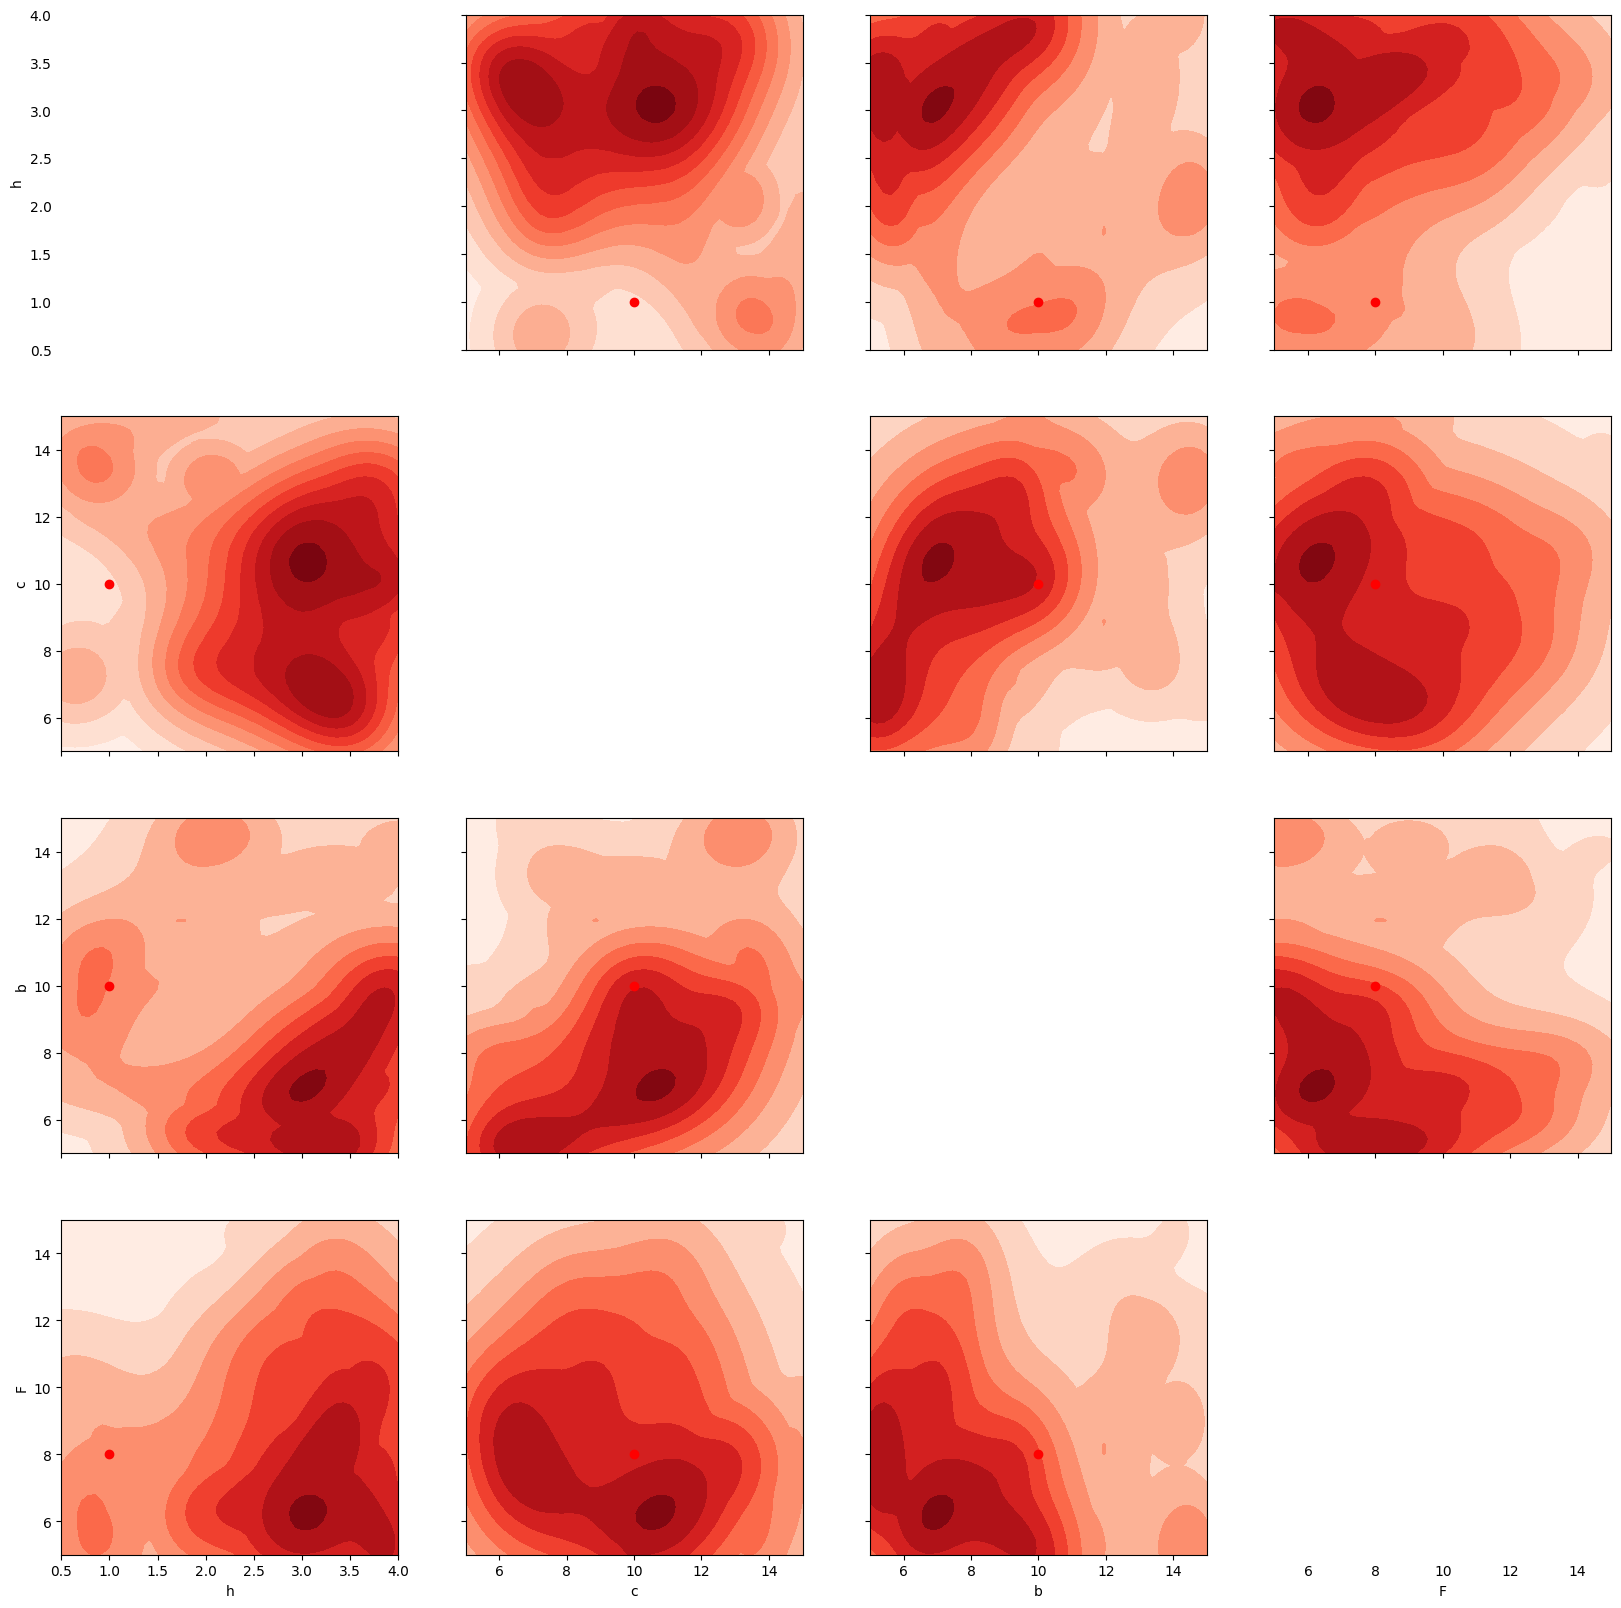

In [49]:
fig,ax = plt.subplots(4,4,figsize=(20,20),sharex='col',sharey='row')    
for i,p1 in enumerate(coords):
    for j,p2 in enumerate(coords):
        if i == 3:
            ax[i][j].set_xlabel(hm_pca.parameter_names[j])
        
        if j == 0:
            ax[i][j].set_ylabel(hm_pca.parameter_names[i])
        if i == j: 
            # ax[i][j].xaxis.set_visible(False)
            ax[i][j].tick_params(left=False,bottom=False)    
              # ax[i][j].yaxis.set_visible(False)
            plt.setp(ax[i][j].spines.values(), visible=False)
            continue

        values = set(range(len(coords))) - {i} - {j}
        X,Y = torch.meshgrid(p2,p1,indexing='xy')
        imp_max = torch.amax(imp_pca,dim=tuple(values))
        if i < j:
            c= ax[i][j].contourf(X,Y,imp_max,cmap='Reds',levels=10)
        if i > j:
            c= ax[i][j].contourf(X,Y,imp_max.T,cmap='Reds',levels=10)

        ax[i][j].scatter(params[hm_pca.parameter_names[j]],params[hm_pca.parameter_names[i]],color='red')

In [50]:
hm_pca.implausibility(torch.tensor([params['h'],params['c'],params['b'],params['F']]).float(),0)

tensor([4.9325], dtype=torch.float64, grad_fn=<CatBackward0>)

### Ensemble Kalman Inversion

In [166]:
from abracalibra.eki import EnsembleKalmanInversion

eki = EnsembleKalmanInversion(params,priors,data,ensemble_size=40,forward=fwd)
optima = eki.calibrate(4)

RuntimeError: expected m1 and m2 to have the same dtype, but got: double != float